In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

In [2]:
BASE_DIR = Path.cwd()
IMAGE_DIR = BASE_DIR / "trainset" / "image"
MASK_DIR = BASE_DIR / "trainset" / "mask"

print("Image dir: ", IMAGE_DIR)
print("Mask dir: ", MASK_DIR)

LABEL_MAP = {
    0: "background",
    1: "cribriform",
    2: "micropapillary",
    3: "solid",
    4: "papillary",
    5: "acinar",
    6: "lepidic",
}
#bo sa od 0 do 6 czyli razem 7 klas
N_CLASSES = 7


Image dir:  c:\Magisterka\trainset\image
Mask dir:  c:\Magisterka\trainset\mask


In [3]:
IMAGE_EXT = {".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"}

image_files = sorted(
    [f for f in IMAGE_DIR.iterdir() if f.suffix.lower() in IMAGE_EXT]
)

print(f"Number of images found: {len(image_files)}")
image_files[:5]

Number of images found: 731


[WindowsPath('c:/Magisterka/trainset/image/train001_Da382.png'),
 WindowsPath('c:/Magisterka/trainset/image/train002_Da425.jpg'),
 WindowsPath('c:/Magisterka/trainset/image/train003_Da449.jpg'),
 WindowsPath('c:/Magisterka/trainset/image/train004_Da473.jpg'),
 WindowsPath('c:/Magisterka/trainset/image/train005_Da106.png')]

In [4]:
def count_pixels_in_mask(mask_path: Path):
    data = loadmat(mask_path)
    mask = data["mask"]
    flat = mask.ravel().astype(np.int64)
    counts = np.bincount(flat, minlength=N_CLASSES)
    return counts

In [5]:
test_mask = MASK_DIR / (image_files[0].stem + ".mat")
counts_test = count_pixels_in_mask(test_mask)
counts_test, dict(zip(LABEL_MAP.values(), counts_test))

(array([1489524,       0,       0,       0,       0,       0, 2510476]),
 {'background': np.int64(1489524),
  'cribriform': np.int64(0),
  'micropapillary': np.int64(0),
  'solid': np.int64(0),
  'papillary': np.int64(0),
  'acinar': np.int64(0),
  'lepidic': np.int64(2510476)})

In [6]:
records = []

for img_path in image_files:
    mask_path = MASK_DIR / (img_path.stem + ".mat")
    
    if not mask_path.exists():
        print(f"Mask not found for image: {img_path.name}")
        continue
    
    counts = count_pixels_in_mask(mask_path)
    total_pixels = counts.sum()
    
    dominant_label_id = np.argmax(counts)
    dominant_label_name = LABEL_MAP[dominant_label_id]
     
    record = {
        "filename": img_path.name,
        "image_path": str(img_path),
        "mask_path": str(mask_path),
        "total_pixels": total_pixels,
        "dominant_label_id": dominant_label_id,
        "dominant_label_name": dominant_label_name,
    }
    
    for label_id, label_name in LABEL_MAP.items():
        record[f"{label_name}_pix"] = counts[label_id]
    
    records.append(record)

df = pd.DataFrame(records)
print("Liczba rekordow w tabeli: ", len(df))
df.head()

Liczba rekordow w tabeli:  731


,filename,image_path,mask_path,total_pixels,dominant_label_id,dominant_label_name,background_pix,cribriform_pix,micropapillary_pix,solid_pix,papillary_pix,acinar_pix,lepidic_pix
0,train001_Da382.png,c:\Magisterka\trainset\image\train001_Da382.png,c:\Magisterka\trainset\mask\train001_Da382.mat,4000000,6,lepidic,1489524,0,0,0,0,0,2510476
1,train002_Da425.jpg,c:\Magisterka\trainset\image\train002_Da425.jpg,c:\Magisterka\trainset\mask\train002_Da425.mat,4000000,0,background,4000000,0,0,0,0,0,0
2,train003_Da449.jpg,c:\Magisterka\trainset\image\train003_Da449.jpg,c:\Magisterka\trainset\mask\train003_Da449.mat,4000000,0,background,4000000,0,0,0,0,0,0
3,train004_Da473.jpg,c:\Magisterka\trainset\image\train004_Da473.jpg,c:\Magisterka\trainset\mask\train004_Da473.mat,4000000,0,background,4000000,0,0,0,0,0,0
4,train005_Da106.png,c:\Magisterka\trainset\image\train005_Da106.png,c:\Magisterka\trainset\mask\train005_Da106.mat,4000000,0,background,4000000,0,0,0,0,0,0


In [7]:
df_used = df.copy()

X = df_used.index.values
y = df_used["dominant_label_id"].values

#70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

df_used["split"] = "none"
df_used.loc[X_train, "split"] = "train"
df_used.loc[X_val, "split"] = "val"
df_used.loc[X_test, "split"] = "test"
df_used["split"].value_counts()

split
train    511
test     110
val      110
Name: count, dtype: int64

In [8]:
for split in ["train", "val", "test"]:
    print(f"\nClass distribution in {split} set:")
    print(
        df_used[df_used["split"] == split]["dominant_label_name"].value_counts().sort_index()
    )


Class distribution in train set:
dominant_label_name
acinar              5
background        338
cribriform         24
lepidic            15
micropapillary     11
papillary          59
solid              59
Name: count, dtype: int64

Class distribution in val set:
dominant_label_name
acinar             1
background        72
cribriform         6
lepidic            3
micropapillary     2
papillary         13
solid             13
Name: count, dtype: int64

Class distribution in test set:
dominant_label_name
acinar             1
background        73
cribriform         5
lepidic            3
micropapillary     2
papillary         13
solid             13
Name: count, dtype: int64


In [29]:
out_csv = BASE_DIR / "luad_patches_with_splits_all_classes.csv"

df_used.to_csv(out_csv, index=False)
out_csv

WindowsPath('c:/Magisterka/luad_patches_with_splits_all_classes.csv')

In [10]:
import shutil

OUTPUT_BASE = BASE_DIR / "dataset_split"

for split in ["train", "val", "test"]:
    (OUTPUT_BASE / split / "image").mkdir(parents=True, exist_ok=True)
    (OUTPUT_BASE / split / "mask").mkdir(parents=True, exist_ok=True)
    
for _, row in df_used.iterrows():
    split = row["split"]
    
    if split not in ["train", "val", "test"]:
        continue
    
    img_src = Path(row["image_path"])
    mask_src = Path(row["mask_path"])
    
    img_dst = OUTPUT_BASE / split / "image" / img_src.name
    mask_dst = OUTPUT_BASE / split / "mask" / mask_src.name
    
    shutil.copy2(img_src, img_dst)
    shutil.copy2(mask_src, mask_dst)


print("Dataset split completed.")

Dataset split completed.


In [11]:
total_per_class = (
    df_used["dominant_label_name"]
    .value_counts()
    .sort_index()
)

print("Łączna liczba próbek per klasa:")
print(total_per_class)

for split in ["train", "val", "test"]:
    print(f"\n=== {split} ===")
    subset = df_used[df_used["split"] == split]["dominant_label_name"].value_counts().sort_index()
    
    # dopasowanie do pełnej listy klas (żeby brakujące klasy dawały 0)
    subset = subset.reindex(total_per_class.index, fill_value=0)
    
    perc = (subset / total_per_class * 100).round(1)
    
    res = pd.DataFrame({
        "liczba": subset,
        "procent w klasie": perc
    })
    print(res)


Łączna liczba próbek per klasa:
dominant_label_name
acinar              7
background        483
cribriform         35
lepidic            21
micropapillary     15
papillary          85
solid              85
Name: count, dtype: int64

=== train ===
                     liczba  procent w klasie
dominant_label_name                          
acinar                    5              71.4
background              338              70.0
cribriform               24              68.6
lepidic                  15              71.4
micropapillary           11              73.3
papillary                59              69.4
solid                    59              69.4

=== val ===
                     liczba  procent w klasie
dominant_label_name                          
acinar                    1              14.3
background               72              14.9
cribriform                6              17.1
lepidic                   3              14.3
micropapillary            2              13.3
papi

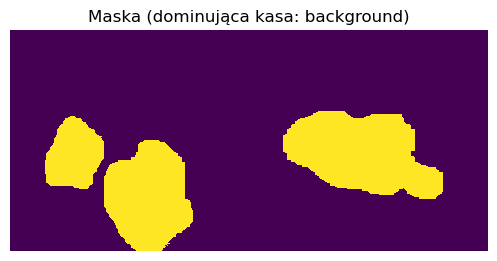

In [ ]:
from PIL import Image

row = df_used.sample(1).iloc[0]

img = Image.open(row["image_path"])
mask = loadmat(row["mask_path"])["mask"]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)

plt.title(f"Obraz: {row['filename']}")
plt.axis("off")

plt.subplot(1, 2, 1)
plt.imshow(mask, interpolation="nearest")
plt.title(f"Maska (dominująca kasa: {row["dominant_label_name"]})")

plt.tight_layout()
plt.show()

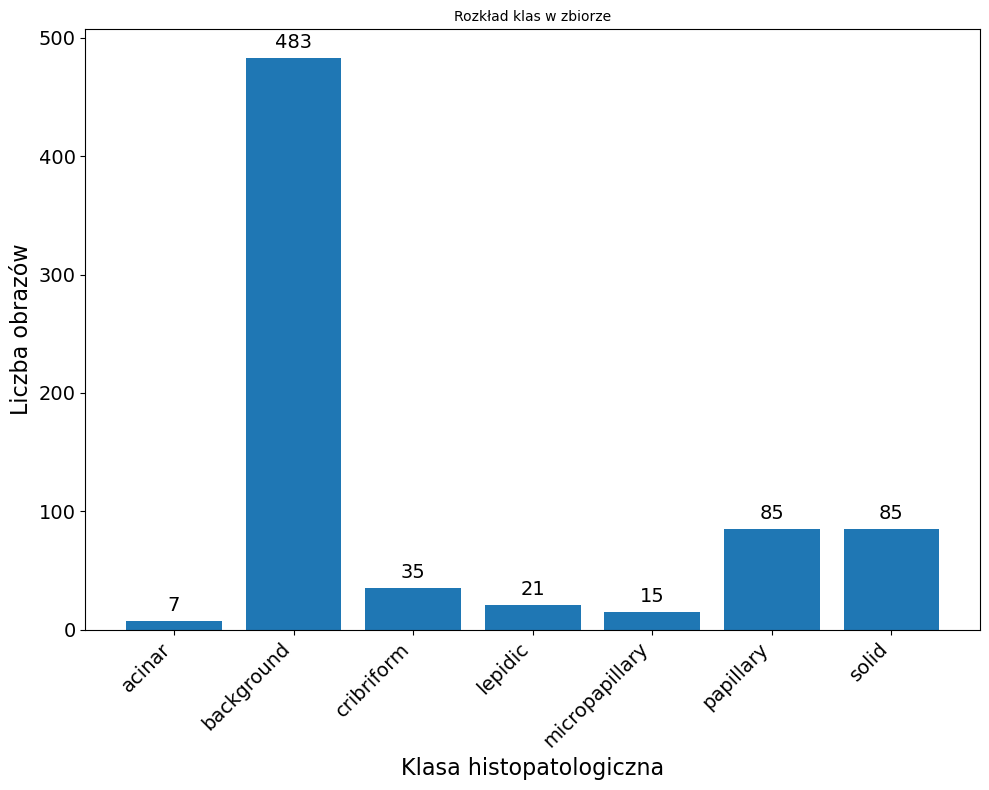

In [35]:
class_counts = (
    df_used["dominant_label_name"].value_counts().sort_index()
)

plt.figure(figsize=(10, 8))

bars = plt.bar(class_counts.index, class_counts.values)

plt.title("Rozkład klas w zbiorze", fontsize=10)
plt.xlabel("Klasa histopatologiczna", fontsize=16)
plt.ylabel("Liczba obrazów", fontsize=16)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        str(height),
        ha="center",
        va="bottom",
        fontsize=14
    )
    
plt.tight_layout()
plt.show()

C:\Users\Mateusz\AppData\Local\Temp\ipykernel_29788\3394704149.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset_counts.index, rotation=45, ha="right", fontsize=12)
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_29788\3394704149.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset_counts.index, rotation=45, ha="right", fontsize=12)
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_29788\3394704149.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(subset_counts.index, rotation=45, ha="right", fontsize=12)


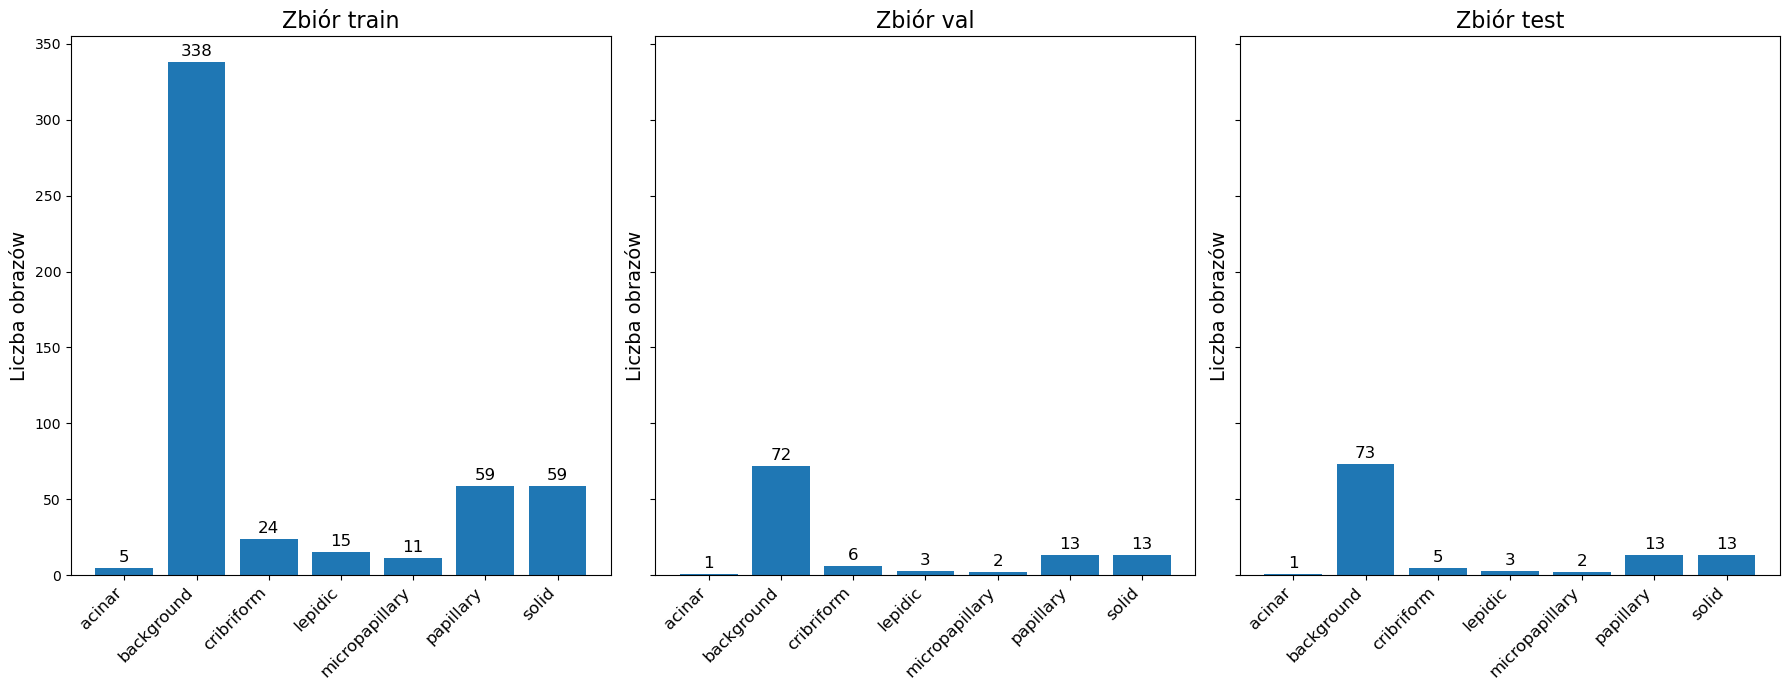

In [ ]:
splits = ["train", "val", "test"]
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, split in zip(axes, splits):
    subset_counts = (
        df_used[df_used["split"] == split]["dominant_label_name"].value_counts().sort_index()
    )
    bars = ax.bar(subset_counts.index, subset_counts.values)
    ax.set_title(f"Zbiór {split}", fontsize=16)
    ax.set_xticklabels(subset_counts.index, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel(f"Liczba obrazów", fontsize=14)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2,
            str(height),
            ha="center",
            va="bottom",
            fontsize=12
        )
        
 #czerwono trening, zielono walidacje, testowy obojętnie       
plt.tight_layout()
plt.show()